In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install  rasterio

In [2]:
import rasterio
import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------------------------------
# 1. THAM SỐ CẤU HÌNH VÀ TỆP
# ----------------------------------------------------
FILE_PATH = "/content/drive/MyDrive/GEE S2_Cloud_2023_MAX_Data/S2_53_TRAINING.tif"

# Thứ tự băng tần (12 Features + 1 SCL)
BAND_INDICES = {
    'B4': 4, 'B8': 8, 'SCL': 13,
    'NIR': 8, 'RED': 4
}
ALL_BANDS_INDICES = list(range(1, 14))


def analyze_s2_data_no_nan(file_path):

    if not Path(file_path).exists():
        print(f"LỖI: Không tìm thấy tệp tại đường dẫn: {file_path}")
        return

    try:
        with rasterio.open(file_path) as src:
            print("A. SIÊU DỮ LIỆU (METADATA)")
            print(f"Kích thước ảnh (W x H): {src.width} x {src.height}")
            print(f"Số băng tần: {src.count}")


            # Đọc tất cả các băng tần
            full_data = src.read(ALL_BANDS_INDICES).astype(np.float32)

            # Dựa vào băng tần đầu tiên để xác định pixel NaN
            valid_mask = ~np.isnan(full_data[0, :, :])
            total_pixels = full_data.shape[1] * full_data.shape[2]
            valid_pixels = np.sum(valid_mask)

            print("\nB. THỐNG KÊ PHẢN XẠ & CHẤT LƯỢNG DỮ LIỆU")
            print(f"Tổng số pixel hợp lệ (non-NaN): {valid_pixels:,} ({valid_pixels/total_pixels*100:.2f}%)")

            stats_list = []
            for i in range(src.count):
                band_data = full_data[i, :, :]
                # Lấy chỉ các giá trị HỢP LỆ (non-NaN)
                valid_band_data = band_data[valid_mask]

                if valid_band_data.size > 0:
                    stats_list.append({
                        'Band': i + 1,
                        'Min': valid_band_data.min(),
                        'Max': valid_band_data.max(),
                        'Mean': valid_band_data.mean(),
                        'Std': valid_band_data.std()
                    })

            df_stats = pd.DataFrame(stats_list)
            print("\n" + df_stats.to_string(index=False))

            # ----------------------------------------------------
            # C. KHAI THÁC DỮ LIỆU NHÃN (SCL)
            # ----------------------------------------------------
            scl_band = full_data[BAND_INDICES['SCL'] - 1, :, :]
            # Lấy chỉ các giá trị SCL HỢP LỆ
            valid_scl = scl_band[valid_mask]

            # Đếm số lượng pixel cho từng mã SCL
            scl_counts = pd.Series(valid_scl).value_counts().sort_index()

            # Ánh xạ các mã SCL phổ biến (tùy thuộc vào cách GEE xuất)
            scl_mapping = {0:'No Data', 1:'Saturated/Defective', 3:'Cloud Shadow',
                           4:'Vegetation', 5:'Not-Vegetated', 6:'Water',
                           7:'Unclassified', 8:'Cloud-Medium', 9:'Cloud-High',
                           10:'Cirrus', 11:'Snow/Ice'}

            # LOẠI BỎ MÃ NaN (Mã 0 - No Data, nếu nó xuất hiện trong dữ liệu hợp lệ)
            if 0 in scl_counts.index:
                scl_counts = scl_counts.drop(0, errors='ignore')

            scl_report = scl_counts.rename(index=scl_mapping)

            print("\nC. PHÂN TÍCH NHÃN SCL (CHỈ PIXEL HỢP LỆ)")
            print(scl_report.to_string())

            # ----------------------------------------------------
            # D. KHAI THÁC DỮ LIỆU PHÁI SINH (NDVI)
            # ----------------------------------------------------

            # Trích xuất băng tần NIR và Red HỢP LỆ
            nir = full_data[BAND_INDICES['NIR'] - 1, :, :][valid_mask]
            red = full_data[BAND_INDICES['RED'] - 1, :, :][valid_mask]

            # Công thức NDVI: (NIR - Red) / (NIR + Red)
            # Đảm bảo phép chia an toàn
            denominator = nir + red

            with np.errstate(divide='ignore', invalid='ignore'):
                 ndvi_values = np.divide(nir - red, denominator,
                                         out=np.zeros_like(denominator, dtype=np.float32),
                                         where=denominator!=0)

            # Lọc bỏ giá trị NaN (xuất hiện nếu mẫu số là 0, mặc dù đã cố gắng tránh)
            ndvi_values = ndvi_values[~np.isnan(ndvi_values)]

            print("\nD. DỮ LIỆU PHÁI SINH (NDVI)")
            print(f"NDVI Min: {np.min(ndvi_values):.4f}")
            print(f"NDVI Max: {np.max(ndvi_values):.4f}")
            print(f"NDVI Mean: {np.mean(ndvi_values):.4f}")

            # Thống kê về mức độ xanh của thực vật
            ndvi_health = np.sum(ndvi_values > 0.4)
            print(f"Số pixel thực vật khỏe mạnh (NDVI > 0.4): {ndvi_health:,}")

            print("="*60)

    except Exception as e:
        print(f"LỖI XỬ LÝ DỮ LIỆU: {e}")

# Chạy phân tích (Đảm bảo đã mount Google Drive)
analyze_s2_data_no_nan(FILE_PATH)

A. SIÊU DỮ LIỆU (METADATA)
Kích thước ảnh (W x H): 7608 x 9087
Số băng tần: 13

B. THỐNG KÊ PHẢN XẠ & CHẤT LƯỢNG DỮ LIỆU
Tổng số pixel hợp lệ (non-NaN): 30,746,032 (44.47%)

 Band    Min     Max     Mean      Std
    1 0.0068  0.9394 0.067310 0.044461
    2 0.0000  1.8744 0.080826 0.040626
    3 0.0000  3.1176 0.106659 0.035325
    4 0.0000  2.6536 0.106463 0.038584
    5 0.0377  1.1130 0.143574 0.036732
    6 0.0403  1.1271 0.201626 0.048896
    7 0.0045  1.1478 0.223144 0.057419
    8 0.0000  2.2424 0.218949 0.062370
    9 0.0000  1.1964 0.233744 0.065253
   10 0.0203  1.3173 0.225979 0.064571
   11 0.0107  1.2605 0.190893 0.073459
   12 0.0000  1.6278 0.137067 0.071016
   13 2.0000 10.0000 5.268514 0.947495

C. PHÂN TÍCH NHÃN SCL (CHỈ PIXEL HỢP LỆ)
2.0                   168
Cloud Shadow         5300
Vegetation          34508
Not-Vegetated    27552804
Water             1184971
Unclassified       391786
Cloud-Medium       770785
Cloud-High           7782
Cirrus             797928

D. 

Loaded /content/drive/MyDrive/GEE S2_Cloud_2023_MAX_Data/S2_1_TRAINING.tif: bands=13, size=9087x7608, dtype=float32
CRS: EPSG:32648
Transform: | 10.00, 0.00, 529910.00|
| 0.00,-10.00, 2365000.00|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=529910.0, bottom=2274130.0, right=605990.0, top=2365000.0)

Per-band statistics:
 band    min     p2     mean  median    p98    max      std
    1 0.1152 0.3828 0.707835  0.7132 0.9721 1.1765 0.141869
    2 0.1112 0.3384 0.602389  0.6064 0.8160 1.0088 0.114598
    3 0.1088 0.3328 0.589125  0.5928 0.7968 0.9896 0.111406
    4 0.0984 0.3264 0.583514  0.5868 0.7920 0.9912 0.111718
    5 0.0871 0.3299 0.596294  0.5991 0.8203 1.0417 0.116575
    6 0.1037 0.3629 0.621636  0.6240 0.8395 1.0601 0.113346
    7 0.1127 0.3879 0.648544  0.6511 0.8665 1.0882 0.114342
    8 0.1230 0.3684 0.605811  0.6076 0.8120 1.0344 0.104919
    9 0.1180 0.3990 0.654138  0.6564 0.8681 1.0886 0.112317
   10 0.0089 0.0772 0.155138  0.1479 0.2813 0.3565 0.049079
   11 0.1033 0.277

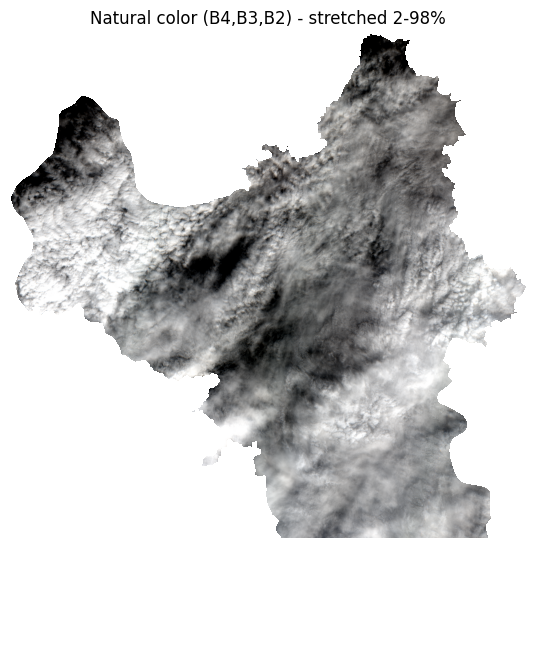

/tmp/ipython-input-2400216619.py:101: RuntimeWarning: invalid value encountered in cast
  quicklook = (rgb * 255).astype('uint8')


Saved quicklook: S2_quicklook_rgb.png


In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

FILE_PATH = "/content/drive/MyDrive/GEE S2_Cloud_2023_MAX_Data/S2_1_TRAINING.tif"

try:
    import rasterio
except Exception as e:
    rasterio = None
    print("rasterio unavailable:", e)
try:
    import tifffile
except Exception:
    tifffile = None

if not Path(FILE_PATH).exists():
    raise FileNotFoundError(f"File not found: {FILE_PATH}")

# Read file (prefer rasterio)
if rasterio:
    with rasterio.open(FILE_PATH) as src:
        arr = src.read()           # shape (bands, rows, cols)
        meta = src.meta
        crs = src.crs
        transform = src.transform
        bounds = src.bounds
else:
    arr = tifffile.imread(FILE_PATH)
    if arr.ndim == 3 and arr.shape[2] < 10:
        arr = np.transpose(arr, (2,0,1))
    meta = {"driver":"TIFF", "dtype":str(arr.dtype)}
    crs = None
    transform = None
    bounds = None

bands, rows, cols = arr.shape
print(f"Loaded {FILE_PATH}: bands={bands}, size={rows}x{cols}, dtype={arr.dtype}")
print("CRS:", crs)
print("Transform:", transform)
print("Bounds:", bounds)

# Per-band statistics
rows_stats = []
for i in range(bands):
    b = arr[i].astype('float32')
    valid = np.isfinite(b)
    if valid.sum() == 0:
        stats = {"band": i+1, "min": np.nan, "p2": np.nan, "mean": np.nan,
                 "median": np.nan, "p98": np.nan, "max": np.nan, "std": np.nan}
    else:
        vals = b[valid].ravel()
        stats = {
            "band": i+1,
            "min": float(np.min(vals)),
            "p2": float(np.percentile(vals, 2)),
            "mean": float(np.mean(vals)),
            "median": float(np.median(vals)),
            "p98": float(np.percentile(vals, 98)),
            "max": float(np.max(vals)),
            "std": float(np.std(vals))
        }
    rows_stats.append(stats)

df = pd.DataFrame(rows_stats)
print("\nPer-band statistics:")
print(df.to_string(index=False))

# helper: stretch using 2-98 percentile
def stretch(band, pmin=2, pmax=98):
    valid = band[np.isfinite(band)]
    if valid.size == 0:
        return band
    lo = np.percentile(valid, pmin)
    hi = np.percentile(valid, pmax)
    if hi == lo:
        return np.clip(band, 0, 1)
    out = (band - lo) / (hi - lo)
    return np.clip(out, 0, 1)

if bands >= 4:
    R = arr[3].astype('float32')
    G = arr[2].astype('float32')
    B = arr[1].astype('float32')
    rgb = np.dstack([stretch(R), stretch(G), stretch(B)])
    plt.figure(figsize=(8,8))
    plt.imshow(rgb)
    plt.title("Natural color (B4,B3,B2) - stretched 2-98%")
    plt.axis('off')
    plt.show()
    # save quicklook
    quicklook = (rgb * 255).astype('uint8')
    outpath = "S2_quicklook_rgb.png"
    plt.imsave(outpath, quicklook)
    print("Saved quicklook:", outpath)
else:
    print("Không đủ kênh để tạo RGB (cần ít nhất 4 kênh).")



/tmp/ipython-input-3885021455.py:27: RuntimeWarning: invalid value encountered in cast
  SCL = src.read(13, window=window).astype(np.int32)  # B13


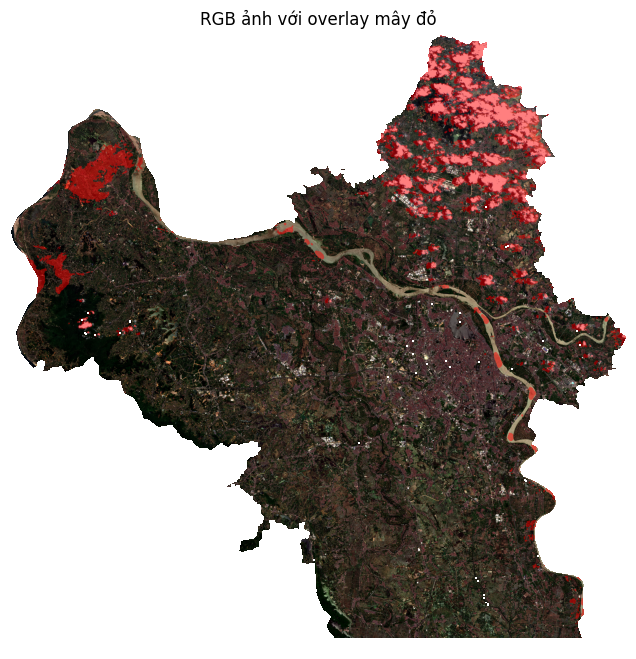

/tmp/ipython-input-3885021455.py:58: RuntimeWarning: invalid value encountered in cast
  quicklook = (rgb*255).astype('uint8')


Saved quicklook: S2_quicklook_rgb_redcloud.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import rasterio
except ImportError:
    rasterio = None


FILE_PATH = "/content/drive/MyDrive/GEE S2_Cloud_2023_MAX_Data/S2_9_TRAINING.tif"
CLOUD_SCL_CODES = [3, 8, 9, 10]
ALPHA = 0.5  # độ mờ overlay đỏ

if not Path(FILE_PATH).exists():
    raise FileNotFoundError(f"File not found: {FILE_PATH}")

# ---- Đọc ảnh (rasterio ưu tiên) ----
with rasterio.open(FILE_PATH) as src:
    height, width = src.height, src.width
    window = rasterio.windows.Window(0, 0, height, width)

    # Đọc băng RGB + SCL
    R = src.read(4, window=window).astype(np.float32)   # B04
    G = src.read(3, window=window).astype(np.float32)   # B03
    B = src.read(2, window=window).astype(np.float32)   # B02
    SCL = src.read(13, window=window).astype(np.int32)  # B13

# ---- Hàm stretch 2-98% ----
def stretch(band, pmin=2, pmax=98):
    valid = band[np.isfinite(band)]
    if valid.size == 0:
        return band
    lo = np.percentile(valid, pmin)
    hi = np.percentile(valid, pmax)
    if hi == lo:
        return np.clip(band, 0, 1)
    out = (band - lo) / (hi - lo)
    return np.clip(out, 0, 1)

# ---- Stack RGB và chuẩn hóa ----
rgb = np.dstack([stretch(R), stretch(G), stretch(B)])

# ---- Overlay mây đỏ ----
cloud_mask = np.isin(SCL, CLOUD_SCL_CODES)
rgb[cloud_mask, 0] = rgb[cloud_mask, 0]*(1-ALPHA) + ALPHA*1.0  # R
rgb[cloud_mask, 1] = rgb[cloud_mask, 1]*(1-ALPHA) + ALPHA*0.0  # G
rgb[cloud_mask, 2] = rgb[cloud_mask, 2]*(1-ALPHA) + ALPHA*0.0  # B

# ---- Hiển thị ----
plt.figure(figsize=(10,8))
plt.imshow(rgb)
plt.title("RGB ảnh với overlay mây đỏ")
plt.axis('off')
plt.show()

# ---- Lưu quicklook ----
quicklook = (rgb*255).astype('uint8')
plt.imsave("S2_quicklook_rgb_redcloud.png", quicklook)
print("Saved quicklook: S2_quicklook_rgb_redcloud.png")


In [4]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.0 MB/s eta 0:00:00


In [17]:
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from catboost import CatBoostClassifier

# ========= CONFIG =========
CSV_PATH = "/content/drive/MyDrive/GEE S2_Data/Traning/S2_237_TRAINING_data.csv"
LABEL_COL = "LABEL"
MODEL_DIR = "models/catboost"
os.makedirs(MODEL_DIR, exist_ok=True)
EPS = 1e-6
BATCH_SIZE = 200_000
BAND_MAP = {
    'B01': 0, 'B02': 1, 'B03': 2, 'B04': 3,
    'B05': 4, 'B06': 5, 'B07': 6, 'B08': 7,
    'B8A': 8, 'B09': 9, 'B10': 10, 'B11': 11, 'B12': 12,
}

# ========= BAND MAP =========
FEATURE_NAMES = [
    'B01','B02','B03','B04','B05','B06','B07','B08','B8A','B09','B11','B12',
    'NDVI','NDSI','NDWI','NDMI',
    'B11_B08_Ratio','B02_B04_Ratio',
    'B8A_B11_Ratio','B01_B11_Ratio',
    'B05_B04_Ratio','B12_B03_Ratio'
]

In [18]:
# ========= 1) LOAD CSV & DROP CỘT THỪA =========
df = pd.read_csv(CSV_PATH)

# chỉ giữ feature + label
df = df[FEATURE_NAMES + [LABEL_COL]]

print("CSV shape after filtering:", df.shape)

# ========= 2) SPLIT X / y =========
X = df[FEATURE_NAMES].values.astype(np.float32)
y = df[LABEL_COL].values.astype(np.int64)

# ========= 3) SCALE =========
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

CSV shape after filtering: (2060000, 23)


In [19]:
# ========= 4) TRAIN / VAL SPLIT =========
X_tr, X_val, y_tr, y_val = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ========= 5) TRAIN CATBOOST =========
cb_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=100
)

cb_model.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val)
)

# ========= 6) EVALUATE =========
y_pred = cb_model.predict(X_val).flatten()
print(classification_report(y_val, y_pred))



0:	learn: 0.9344226	test: 0.9350140	best: 0.9350140 (0)	total: 631ms	remaining: 2m 5s
100:	learn: 0.9477581	test: 0.9477579	best: 0.9477579 (100)	total: 1m 5s	remaining: 1m 4s
199:	learn: 0.9499382	test: 0.9498727	best: 0.9498727 (199)	total: 2m 10s	remaining: 0us

bestTest = 0.9498727332
bestIteration = 199

              precision    recall  f1-score   support

           0       0.86      0.87      0.87    112000
           1       0.95      0.95      0.95    300000

    accuracy                           0.93    412000
   macro avg       0.91      0.91      0.91    412000
weighted avg       0.93      0.93      0.93    412000



In [20]:
# ========= UTILS =========
def safe_div(a, b):
    return a / (b + EPS)

def read_tif_13band(path):
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)   # (13, H, W)
    return img

def compute_indices(img):
    B = lambda k: img[BAND_MAP[k]]
    return {
        'NDVI': safe_div(B('B08') - B('B04'), B('B08') + B('B04')),
        'NDSI': safe_div(B('B03') - B('B11'), B('B03') + B('B11')),
        'NDWI': safe_div(B('B03') - B('B08'), B('B03') + B('B08')),
        'NDMI': safe_div(B('B08') - B('B11'), B('B08') + B('B11')),
        'B11_B08_Ratio': safe_div(B('B11'), B('B08')),
        'B02_B04_Ratio': safe_div(B('B02'), B('B04')),
        'B8A_B11_Ratio': safe_div(B('B8A'), B('B11')),
        'B01_B11_Ratio': safe_div(B('B01'), B('B11')),
        'B05_B04_Ratio': safe_div(B('B05'), B('B04')),
        'B12_B03_Ratio': safe_div(B('B12'), B('B03')),
    }

def build_feature_matrix(img):
    H, W = img.shape[1], img.shape[2]
    idx_feats = compute_indices(img)

    stack = []
    for name in FEATURE_NAMES:
        if name in BAND_MAP:
            stack.append(img[BAND_MAP[name]])
        else:
            stack.append(idx_feats[name])

    X = np.stack(stack, axis=0).reshape(len(FEATURE_NAMES), -1).T
    return X, H, W

In [9]:
def cloud_fbeta_df(gt_df, pred_df, beta=2):
    df = gt_df.merge(
        pred_df,
        on=["image_id", "px", "py"],
        suffixes=("_gt", "_pred")
    )

    tp = ((df.label_gt == 1) & (df.label_pred == 1)).sum()
    fp = ((df.label_gt == 0) & (df.label_pred == 1)).sum()
    fn = ((df.label_gt == 1) & (df.label_pred == 0)).sum()

    score = (1 + beta**2) * tp / (
        (1 + beta**2) * tp + beta**2 * fn + fp + 1e-9
    )
    return score


In [10]:
def f2_score_np(y_true, y_pred):
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    return 5 * tp / (5 * tp + 4 * fn + fp + 1e-9)


In [24]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window
import pandas as pd

# ================= CONFIG =================
TIF_DIR = "/content/drive/MyDrive/GEE S2_Cloud_2023_MAX_Data/Test(28 5)"
TILE_SIZE = 512
CLOUD_THRESHOLD = 0.5

# ================= MAIN =================
def predict_folder_to_dataframe():
    records = []

    tif_files = sorted([f for f in os.listdir(TIF_DIR) if f.endswith(".tif")])
    print(f"Found {len(tif_files)} tif files")

    for tif_name in tif_files:
        tif_path = os.path.join(TIF_DIR, tif_name)
        image_id = os.path.splitext(tif_name)[0]

        print(f"Processing {image_id}")

        with rasterio.open(tif_path) as src:
            H, W = src.height, src.width

            for row in range(0, H, TILE_SIZE):
                for col in range(0, W, TILE_SIZE):
                    h = min(TILE_SIZE, H - row)
                    w = min(TILE_SIZE, W - col)
                    window = Window(col, row, w, h)

                    img = src.read(window=window).astype(np.float32)

                    valid_mask = (
                        np.all(np.isfinite(img), axis=0) &
                        np.all(img > 0, axis=0)
                    )

                    if valid_mask.sum() == 0:
                        continue

                    X, _, _ = build_feature_matrix(img)
                    flat_valid = valid_mask.reshape(-1)

                    X_valid = scaler.transform(X[flat_valid])
                    probs_valid = cb_model.predict_proba(X_valid)[:, 1]

                    probs = np.zeros(h * w, dtype=np.float32)
                    probs[flat_valid] = probs_valid
                    probs = probs.reshape(h, w)

                    cloud_mask = (probs >= CLOUD_THRESHOLD) & valid_mask


                    ys, xs = np.where(valid_mask)
                    for y, x in zip(ys, xs):
                        records.append([
                            image_id,
                            col + x,
                            row + y,
                            int(cloud_mask[y, x])
                        ])

    submission_df = pd.DataFrame(
        records,
        columns=["image_id", "px", "py", "label"]
    )

    print(f"\nTotal predicted pixels: {len(submission_df)}")
    return submission_df

submission_df = predict_folder_to_dataframe()
submission_df.head()


Found 46 tif files
Processing tile_00002_R2048C0
Processing tile_00006_R1536C512
Processing tile_00007_R2048C512
Processing tile_00008_R2560C512
Processing tile_00009_R3072C512
Processing tile_00010_R3584C512
Processing tile_00012_R1024C1024
Processing tile_00013_R1536C1024
Processing tile_00014_R2048C1024
Processing tile_00015_R2560C1024
Processing tile_00020_R3072C1536
Processing tile_00021_R3584C1536
Processing tile_00022_R4096C1536
Processing tile_00025_R3072C2048
Processing tile_00026_R3584C2048
Processing tile_00027_R4096C2048
Processing tile_00028_R4608C2048
Processing tile_00030_R2560C2560
Processing tile_00031_R4608C2560
Processing tile_00036_R3072C3072
Processing tile_00037_R3584C3072
Processing tile_00038_R4096C3072
Processing tile_00039_R4608C3072
Processing tile_00040_R5120C3072
Processing tile_00041_R5632C3072
Processing tile_00043_R2560C3584
Processing tile_00044_R4096C3584
Processing tile_00045_R4608C3584
Processing tile_00046_R5120C3584
Processing tile_00047_R6656C3584

,image_id,px,py,label
0,tile_00002_R2048C0,345,0,1
1,tile_00002_R2048C0,346,0,1
2,tile_00002_R2048C0,347,0,1
3,tile_00002_R2048C0,348,0,1
4,tile_00002_R2048C0,349,0,1


In [25]:
TEST_CSV = "/content/drive/MyDrive/GEE S2_Cloud_2023_MAX_Data/Test(28 5)/Output/test.csv"
gt_df = pd.read_csv(TEST_CSV)

print("GT pixels:", len(gt_df))
print("Pred pixels:", len(submission_df))


GT pixels: 12058624
Pred pixels: 11577305


In [ ]:
score = cloud_fbeta_df(gt_df, submission_df, beta=2)
print("F2 score:", score)